# Импорт библиотек

In [64]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

# Загрузка данных

In [65]:
data = pd.read_csv('./train.csv')
test = pd.read_csv("test.csv")
submission = pd.read_csv('./submission.csv')

# Основная информация о тренировочных данных

Посмотрим на случайные строчки

In [66]:
data.sample(5)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
114,7,23.50,173,Male,0,No,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,0
4071,6,49.25,255.6,Female,0,No,No,No,No phone service,DSL,No,No,No,Yes,Yes,Yes,One year,Yes,Mailed check,0
4390,31,89.45,2807.65,Male,1,Yes,No,Yes,Yes,Fiber optic,Yes,No,No,No,Yes,No,Month-to-month,No,Electronic check,0
1370,72,53.65,3784,Female,0,Yes,Yes,No,No phone service,DSL,No,Yes,No,Yes,Yes,Yes,Two year,No,Credit card (automatic),0
1514,72,25.75,1864.2,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0


Выделим числовые признаки, категориальные признаки и таргет

In [67]:
num_cols = [
    'ClientPeriod',
    'MonthlySpending',
    'TotalSpent'
]

cat_cols = [
    'Sex',
    'IsSeniorCitizen',
    'HasPartner',
    'HasChild',
    'HasPhoneService',
    'HasMultiplePhoneNumbers',
    'HasInternetService',
    'HasOnlineSecurityService',
    'HasOnlineBackup',
    'HasDeviceProtection',
    'HasTechSupportAccess',
    'HasOnlineTV',
    'HasMovieSubscription',
    'HasContractPhone',
    'IsBillingPaperless',
    'PaymentMethod'
]

feature_cols = num_cols + cat_cols
target_col = 'Churn'

Размер тренировочных данных

In [68]:
data.shape

(5282, 20)

Получим основную информацию о признаках

In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5282 entries, 0 to 5281
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              5282 non-null   int64  
 1   MonthlySpending           5282 non-null   float64
 2   TotalSpent                5282 non-null   object 
 3   Sex                       5282 non-null   object 
 4   IsSeniorCitizen           5282 non-null   int64  
 5   HasPartner                5282 non-null   object 
 6   HasChild                  5282 non-null   object 
 7   HasPhoneService           5282 non-null   object 
 8   HasMultiplePhoneNumbers   5282 non-null   object 
 9   HasInternetService        5282 non-null   object 
 10  HasOnlineSecurityService  5282 non-null   object 
 11  HasOnlineBackup           5282 non-null   object 
 12  HasDeviceProtection       5282 non-null   object 
 13  HasTechSupportAccess      5282 non-null   object 
 14  HasOnlin

Получим основную статистическую информацию о числовых признаках

In [70]:
data.describe()

,ClientPeriod,MonthlySpending,IsSeniorCitizen,Churn
count,5282.000000,5282.000000,5282.000000,5282.000000
mean,32.397009,64.924754,0.159409,0.262022
std,24.550326,30.176464,0.366092,0.439776
min,0.000000,18.250000,0.000000,0.000000
25%,9.000000,35.462500,0.000000,0.000000
50%,29.000000,70.400000,0.000000,0.000000
75%,55.000000,90.050000,0.000000,1.000000
max,72.000000,118.750000,1.000000,1.000000


Проверим есть ли пропущенные значения

In [71]:
data.isna().any()

ClientPeriod                False
MonthlySpending             False
TotalSpent                  False
Sex                         False
IsSeniorCitizen             False
HasPartner                  False
HasChild                    False
HasPhoneService             False
HasMultiplePhoneNumbers     False
HasInternetService          False
HasOnlineSecurityService    False
HasOnlineBackup             False
HasDeviceProtection         False
HasTechSupportAccess        False
HasOnlineTV                 False
HasMovieSubscription        False
HasContractPhone            False
IsBillingPaperless          False
PaymentMethod               False
Churn                       False
dtype: bool

Выведем количество пропущенных значений в каждом столбце

In [72]:
data.isna().sum()

ClientPeriod                0
MonthlySpending             0
TotalSpent                  0
Sex                         0
IsSeniorCitizen             0
HasPartner                  0
HasChild                    0
HasPhoneService             0
HasMultiplePhoneNumbers     0
HasInternetService          0
HasOnlineSecurityService    0
HasOnlineBackup             0
HasDeviceProtection         0
HasTechSupportAccess        0
HasOnlineTV                 0
HasMovieSubscription        0
HasContractPhone            0
IsBillingPaperless          0
PaymentMethod               0
Churn                       0
dtype: int64

Посмотрим есть ли дубликаты в наших данных

In [73]:
data.duplicated().sum()

14

В data.info() можно заметить что колонка data["TotalSpent"] object, хотя кажеться что он должен быть float. И если мы попытемся перевести его во float, то увидем, что там есть значение " ". Исправим это и будем считать, что там стоит 0

In [74]:
try:
    data = data["TotalSpent"].astype(float)
except ValueError as e:
    print(f"Произошла ошибка: {e}")

Произошла ошибка: could not convert string to float: ' '


In [75]:
data["TotalSpent"] = data["TotalSpent"].str.replace(" ", "0").astype(float)

Проверим, что произошла замена

In [76]:
data[data["TotalSpent"] == " "] 

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn


# Основная информация о тестовых данных

In [77]:
test.sample(5)

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod
439,2,86.25,181.65,Female,0,No,No,Yes,No,Fiber optic,Yes,Yes,No,Yes,No,No,Month-to-month,Yes,Electronic check
800,66,80.45,5224.35,Female,1,No,No,Yes,Yes,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Credit card (automatic)
518,18,85.60,1601.5,Male,0,Yes,Yes,Yes,No,Fiber optic,No,No,No,Yes,No,Yes,Month-to-month,Yes,Electronic check
1231,1,44.75,44.75,Male,0,No,No,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
898,71,106.70,7382.25,Male,0,No,Yes,Yes,Yes,Fiber optic,Yes,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic)


Выделим числовые, категориальные признаки и таргет

Размер тренировочных данных

In [78]:
test.shape

(1761, 19)

Получим основную информацию о признаках

In [79]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ClientPeriod              1761 non-null   int64  
 1   MonthlySpending           1761 non-null   float64
 2   TotalSpent                1761 non-null   object 
 3   Sex                       1761 non-null   object 
 4   IsSeniorCitizen           1761 non-null   int64  
 5   HasPartner                1761 non-null   object 
 6   HasChild                  1761 non-null   object 
 7   HasPhoneService           1761 non-null   object 
 8   HasMultiplePhoneNumbers   1761 non-null   object 
 9   HasInternetService        1761 non-null   object 
 10  HasOnlineSecurityService  1761 non-null   object 
 11  HasOnlineBackup           1761 non-null   object 
 12  HasDeviceProtection       1761 non-null   object 
 13  HasTechSupportAccess      1761 non-null   object 
 14  HasOnlin

Получим основную статистическую информацию о числовых признаках

In [80]:
test.describe()

,ClientPeriod,MonthlySpending,IsSeniorCitizen
count,1761.000000,1761.000000,1761.000000
mean,32.293583,64.272601,0.170358
std,24.593736,29.832517,0.376054
min,0.000000,18.550000,0.000000
25%,9.000000,35.650000,0.000000
50%,29.000000,70.050000,0.000000
75%,56.000000,89.400000,0.000000
max,72.000000,117.350000,1.000000


Проверим есть ли пропущенные значения

In [81]:
test.isna().any()

ClientPeriod                False
MonthlySpending             False
TotalSpent                  False
Sex                         False
IsSeniorCitizen             False
HasPartner                  False
HasChild                    False
HasPhoneService             False
HasMultiplePhoneNumbers     False
HasInternetService          False
HasOnlineSecurityService    False
HasOnlineBackup             False
HasDeviceProtection         False
HasTechSupportAccess        False
HasOnlineTV                 False
HasMovieSubscription        False
HasContractPhone            False
IsBillingPaperless          False
PaymentMethod               False
dtype: bool

Вывелем количество пропущенных значений в каждом столбце

In [82]:
test.isna().sum()

ClientPeriod                0
MonthlySpending             0
TotalSpent                  0
Sex                         0
IsSeniorCitizen             0
HasPartner                  0
HasChild                    0
HasPhoneService             0
HasMultiplePhoneNumbers     0
HasInternetService          0
HasOnlineSecurityService    0
HasOnlineBackup             0
HasDeviceProtection         0
HasTechSupportAccess        0
HasOnlineTV                 0
HasMovieSubscription        0
HasContractPhone            0
IsBillingPaperless          0
PaymentMethod               0
dtype: int64

Посмотрим есть ли дубликаты в наших данных

In [83]:
test.duplicated().sum()

3

В test.info() можно заметить что колонка test["TotalSpent"] object, хотя кажеться что он должен быть float. И если мы попытемся перевести его во float, то увидем, что там есть значение " ". Исправим это и будем считать, что там стоит 0

In [84]:
try:
    test["TotalSpent"] = test["TotalSpent"].astype(float)
except ValueError as e:
    print(f"Произошла ошибка: {e}")

Произошла ошибка: could not convert string to float: ' '


In [85]:
test["TotalSpent"] = test["TotalSpent"].str.replace(" ", "0").astype(float)

Проверим, что произошла замена

In [86]:
test[test["TotalSpent"] == " "] 

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod


# Анализ тренировочных данных

Для численных признаков построим гистограммы

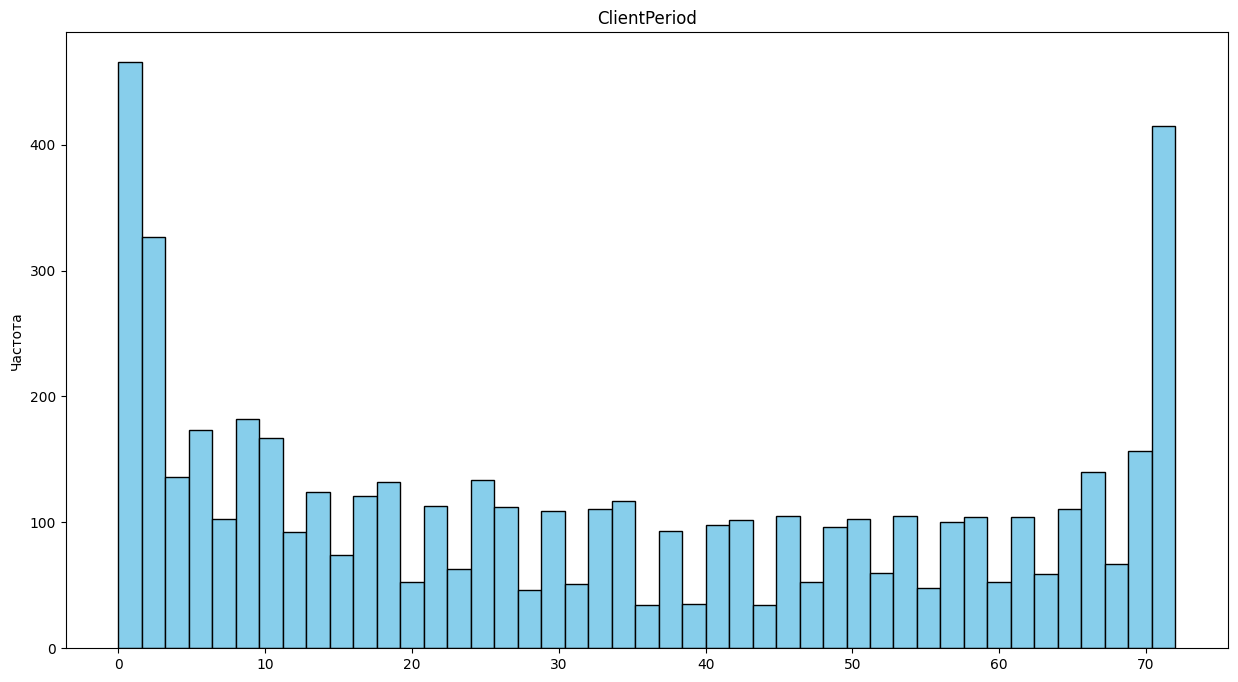

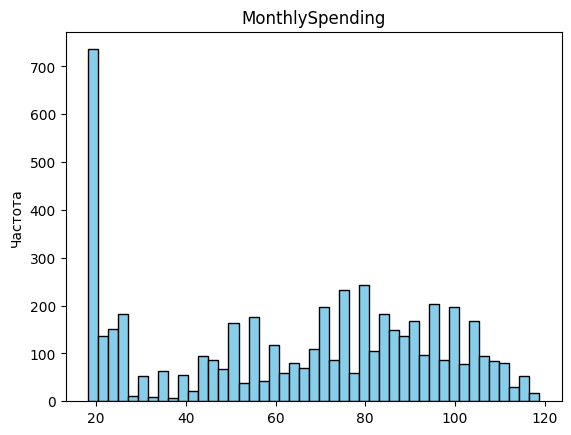

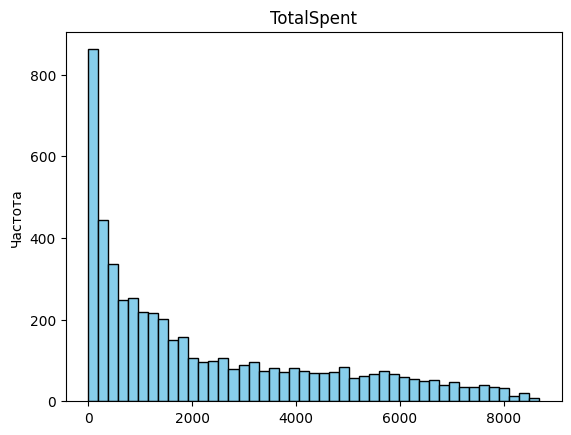

In [24]:
plt.figure(figsize=(15, 8))
for a in num_cols:
    plt.hist(data[a], bins=45, color='skyblue', edgecolor='black')
    plt.ylabel('Частота')
    plt.title(f"{a}")
    plt.show()

Построим распределение целевой переменной

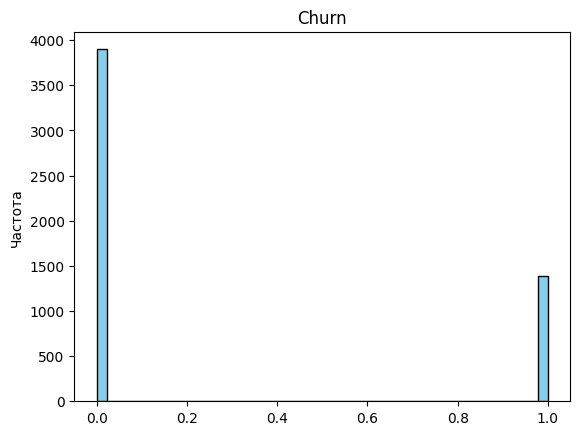

In [25]:
plt.hist(data["Churn"], bins=45, color='skyblue', edgecolor='black')
plt.ylabel('Частота')
plt.title("Churn")
plt.show()

Видно, что классы несбалансированы 

Для категориальных признаков посчитаем количество каждого значения для каждого признака.

In [26]:
for i in cat_cols:
    data[i].value_counts()
    print(f"Признак '{i}':")
    print(data[i].value_counts())
    print()

Признак 'Sex':
Sex
Male      2655
Female    2627
Name: count, dtype: int64

Признак 'IsSeniorCitizen':
IsSeniorCitizen
0    4440
1     842
Name: count, dtype: int64

Признак 'HasPartner':
HasPartner
No     2705
Yes    2577
Name: count, dtype: int64

Признак 'HasChild':
HasChild
No     3676
Yes    1606
Name: count, dtype: int64

Признак 'HasPhoneService':
HasPhoneService
Yes    4761
No      521
Name: count, dtype: int64

Признак 'HasMultiplePhoneNumbers':
HasMultiplePhoneNumbers
No                  2511
Yes                 2250
No phone service     521
Name: count, dtype: int64

Признак 'HasInternetService':
HasInternetService
Fiber optic    2341
DSL            1800
No             1141
Name: count, dtype: int64

Признак 'HasOnlineSecurityService':
HasOnlineSecurityService
No                     2612
Yes                    1529
No internet service    1141
Name: count, dtype: int64

Признак 'HasOnlineBackup':
HasOnlineBackup
No                     2332
Yes                    1809
No inter

Для каждого категориального признака нарисуем круговые диаграммы

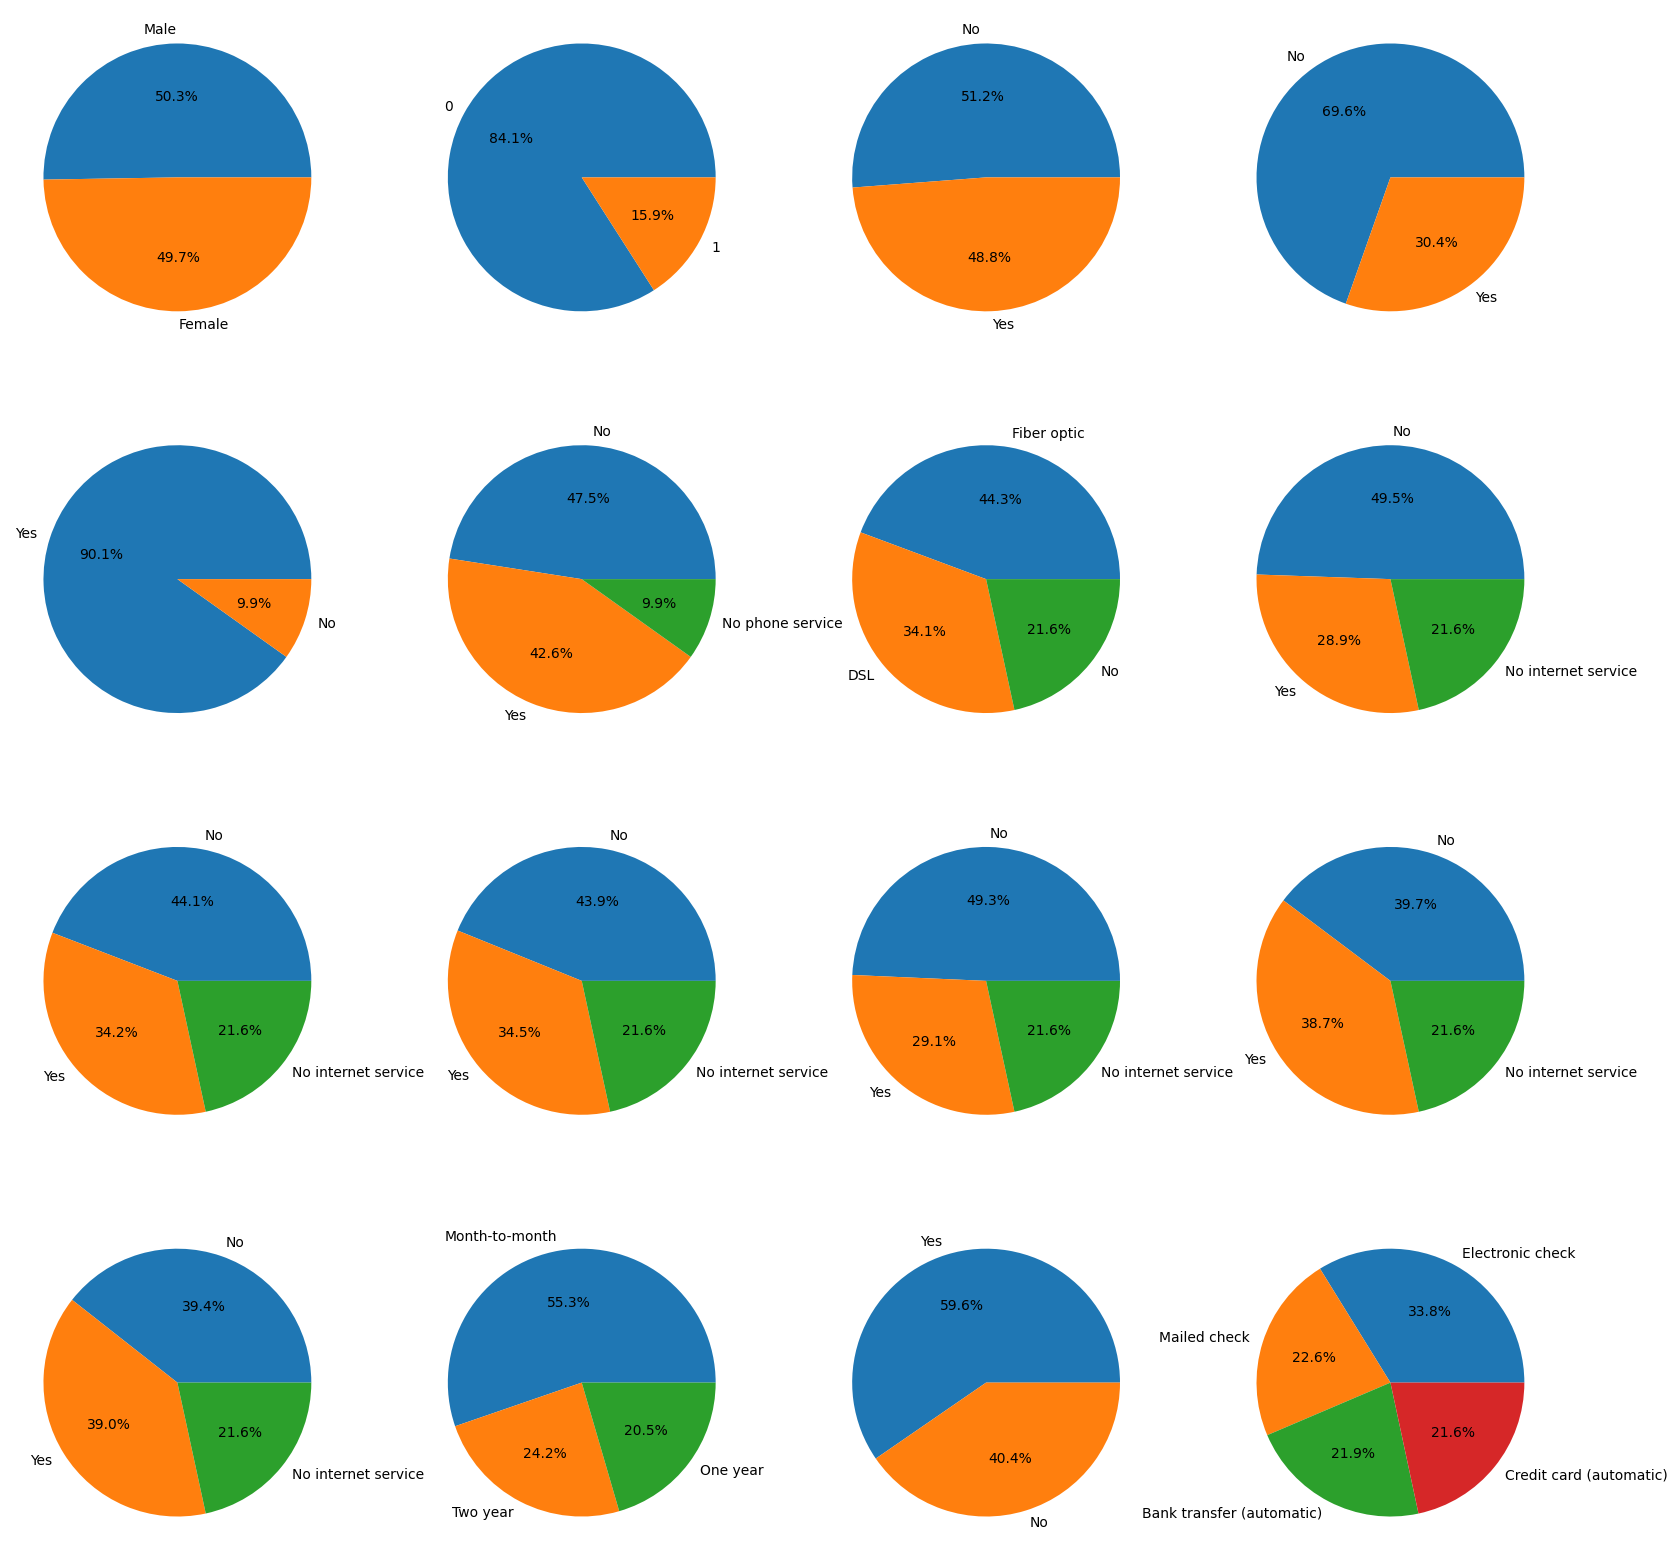

In [27]:
plt.figure(figsize=(20, 20))
for i, column in enumerate(cat_cols):
    plt.subplot(4, 4, i + 1)
    plt.pie(data[column].value_counts(), autopct="%.1f%%", labels=data[column].value_counts().index)

        

Визуализировать попарную корреляцию Пирсона между всеми признаками

<Axes: >

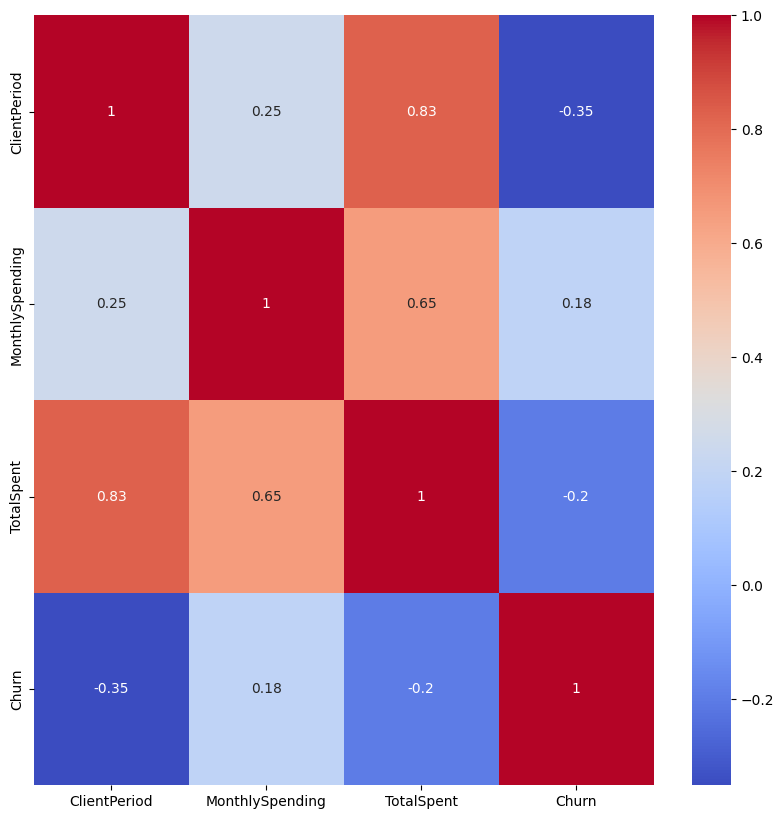

In [28]:
cor_cols = ['ClientPeriod', 'MonthlySpending', 'TotalSpent', 'Churn']
correlation_matrix = data[cor_cols].corr()
fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

# Анализ тестовых данных

Для численных признаков построим гистограммы

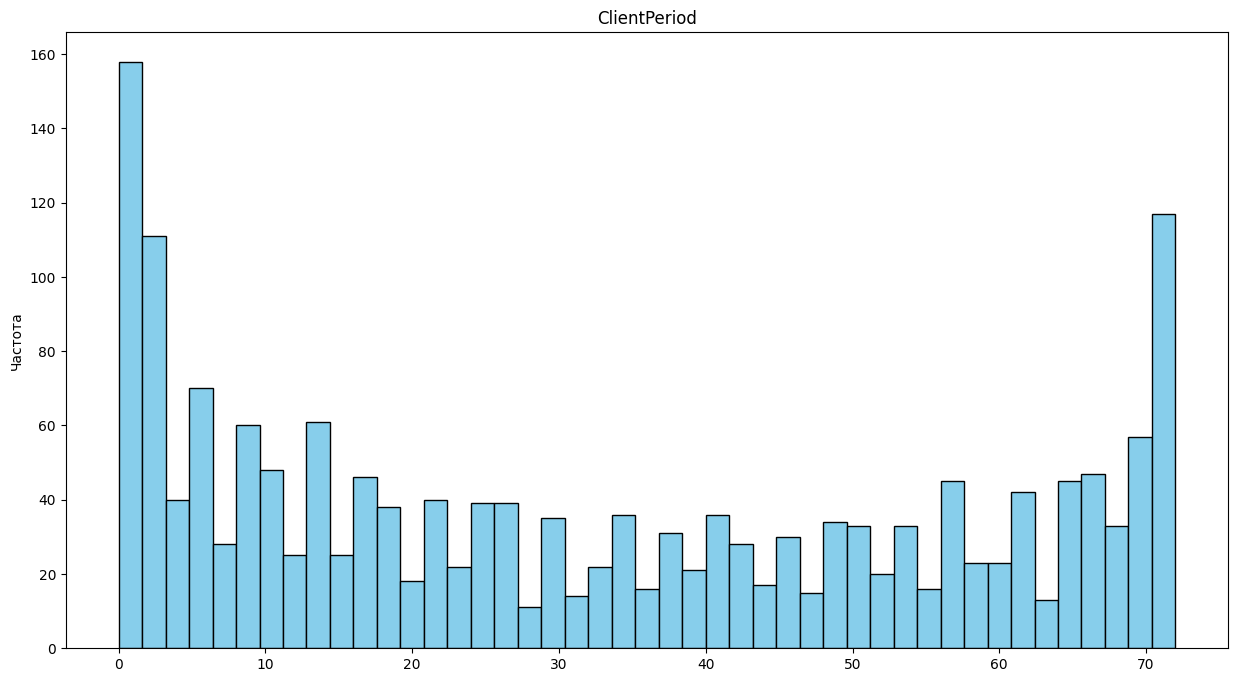

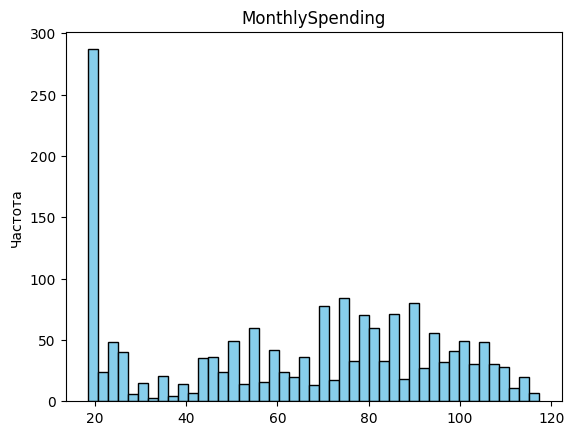

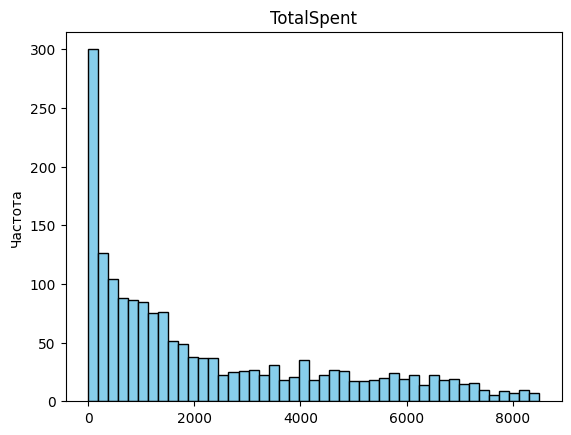

In [29]:
plt.figure(figsize=(15, 8))
for a in num_cols:
    plt.hist(test[a], bins=45, color='skyblue', edgecolor='black')
    plt.ylabel('Частота')
    plt.title(f"{a}")
    plt.show()

Для категориальных признаков посчитаем количество каждого значения для каждого признака.

In [30]:
for i in cat_cols:
    test[i].value_counts()
    print(f"Признак '{i}':")
    print(test[i].value_counts())
    print()

Признак 'Sex':
Sex
Male      900
Female    861
Name: count, dtype: int64

Признак 'IsSeniorCitizen':
IsSeniorCitizen
0    1461
1     300
Name: count, dtype: int64

Признак 'HasPartner':
HasPartner
No     936
Yes    825
Name: count, dtype: int64

Признак 'HasChild':
HasChild
No     1257
Yes     504
Name: count, dtype: int64

Признак 'HasPhoneService':
HasPhoneService
Yes    1600
No      161
Name: count, dtype: int64

Признак 'HasMultiplePhoneNumbers':
HasMultiplePhoneNumbers
No                  879
Yes                 721
No phone service    161
Name: count, dtype: int64

Признак 'HasInternetService':
HasInternetService
Fiber optic    755
DSL            621
No             385
Name: count, dtype: int64

Признак 'HasOnlineSecurityService':
HasOnlineSecurityService
No                     886
Yes                    490
No internet service    385
Name: count, dtype: int64

Признак 'HasOnlineBackup':
HasOnlineBackup
No                     756
Yes                    620
No internet service    

Для каждого категориального признака нарисуем круговые диаграммы

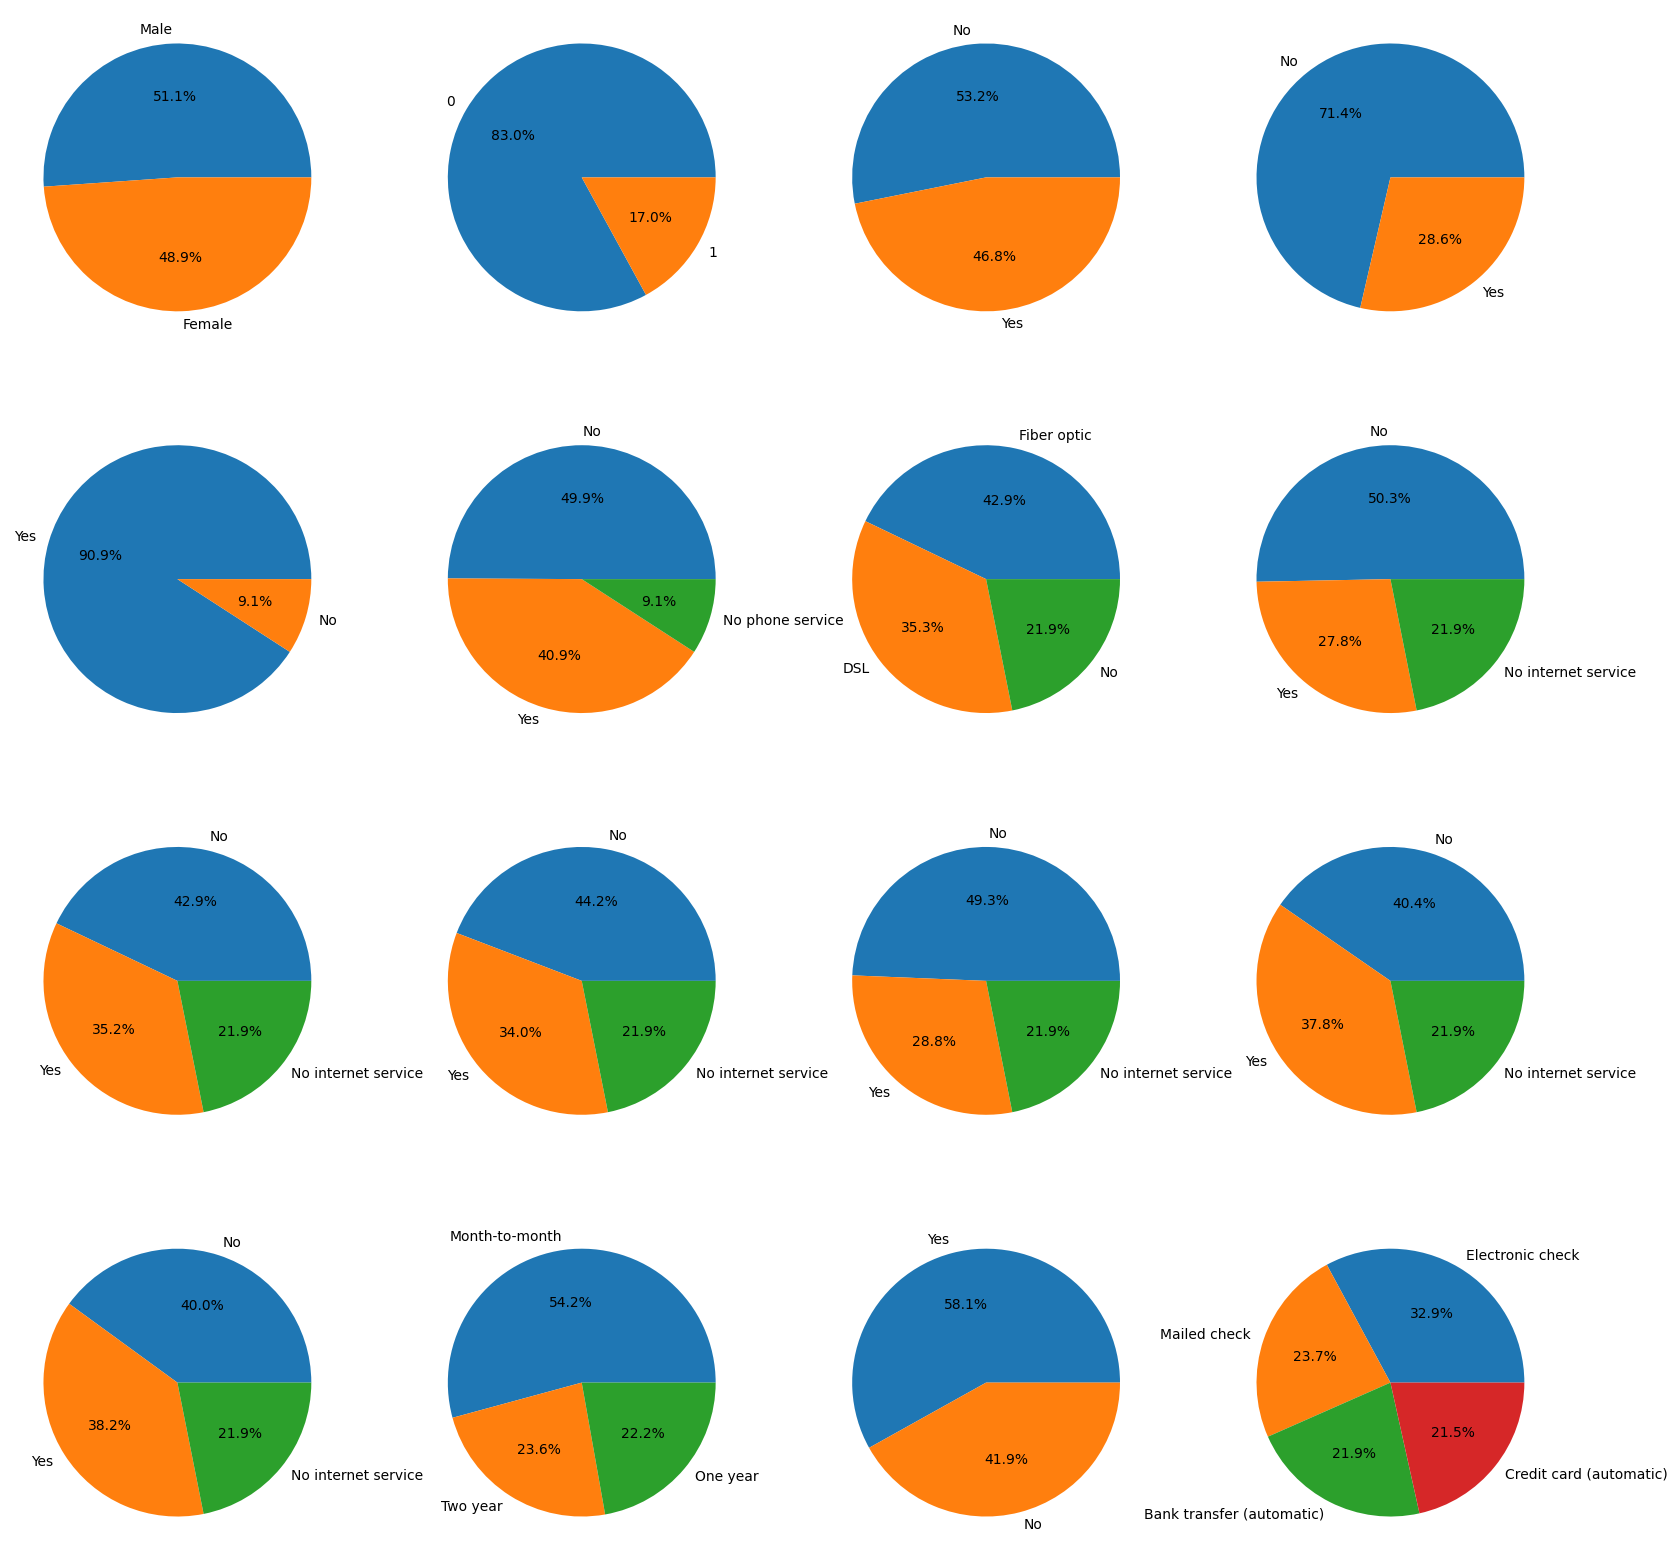

In [31]:
plt.figure(figsize=(20, 20))
for i, column in enumerate(cat_cols):
    plt.subplot(4, 4, i + 1)
    plt.pie(test[column].value_counts(), autopct="%.1f%%", labels=test[column].value_counts().index)

        

# Применение линейных моделей 

In [87]:
X = data.drop(target_col, axis = 1)
y = data[target_col]

Отнормируем числовые признаки

In [88]:
num_transformer = Pipeline(steps=[('scaler', StandardScaler()),])

Категориальные закодируем с помощью one-hot-encoding'а

In [108]:
cat_transformer = Pipeline(steps=[('ohe', OneHotEncoder(drop='first', handle_unknown='error')),])

Конечный Pipeline

In [109]:
cls = ColumnTransformer(transformers=[('cat', cat_transformer, cat_cols),('num', num_transformer, num_cols),])
final_pipe = Pipeline(steps=[('preprocessor', cls), ('model', LogisticRegression())])

С помощью кроссвалидации протестируем разные значения гиперпараметра C и выберем лучший (можно тестировать С=100, 10, 1, 0.1, 0.01, 0.001) по метрике ROC-AUC.

In [110]:
parameters = {'model__C': [100, 10, 1, 0.1, 0.01, 0.001]}
CV_model = GridSearchCV(final_pipe, param_grid= parameters, cv = 5, scoring ="roc_auc", n_jobs=-1,verbose=0)
CV_model.fit(X, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('ohe',
                                                                                          OneHotEncoder(drop='first'))]),
                                                                         ['Sex',
                                                                          'IsSeniorCitizen',
                                                                          'HasPartner',
                                                                          'HasChild',
                                                                          'HasPhoneService',
                                                                          'HasMultiplePhoneNumbers',
                                                                          'HasInternetService',
                                                                          'HasOnlineSecurityService',
                                                                          'HasOnlineBackup',
                                                                          'HasDeviceProtection',
                                                                          'HasTechSupportAccess',
                                                                          'HasOnlineTV',
                                                                          'HasMovieSubscription',
                                                                          'HasContractPhone',
                                                                          'IsBillingPaperless',
                                                                          'PaymentMethod']),
                                                                        ('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['ClientPeriod',
                                                                          'MonthlySpending',
                                                                          'TotalSpent'])])),
                                       ('model', LogisticRegression())]),
             n_jobs=-1, param_grid={'model__C': [100, 10, 1, 0.1, 0.01, 0.001]},
             scoring='roc_auc')

Лучшие параметры

In [111]:
CV_model.best_params_

{'model__C': 10}

Лучший результат

In [112]:
CV_model.best_score_

0.8451399367114021

# Применение градиентного бустинга

Загрузим данные

In [95]:
X = data.drop(target_col, axis = 1)
y = data[target_col]

Разделим выборку на train/valid.

In [96]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

Протестируем catboost cо стандартными параметрами.

In [97]:
model = CatBoostClassifier(cat_features=cat_cols, verbose=False)
model.fit(X_train, y_train)

Результат

In [98]:
roc_auc_score(y_val, model.predict_proba(X_val)[:,1])

0.823387759625419

Протестируем разные занчения параметроа количества деревьев и learning_rate и выберем лучшую по метрике ROC-AUC комбинацию.

In [99]:
best_roc_auc = 0
best_params = None
for n_iterations in [250, 500, 1000]:
    for lr in [0.01, 0.05, 0.001]:
        model = CatBoostClassifier(iterations=n_iterations, learning_rate=lr, cat_features=cat_cols, verbose=False)
        model.fit(X_train, y_train)
        roc_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:,1])
        if roc_auc > best_roc_auc:
            best_roc_auc = roc_auc
            best_params = {'iterations': n_iterations, 'learning_rate': lr}

Лучший результат

In [100]:
best_roc_auc

0.8314847480167342

Лучшие параметры

In [101]:
best_params

{'iterations': 1000, 'learning_rate': 0.01}

Проверка работы кросс-валидации с большим количеством гиперпараметров

In [102]:
param_grid = {'depth': [2, 4, 6],
              'learning_rate' : [0.01, 0.05, 0.1],
              'iterations': [250, 500],
              'l2_leaf_reg': [0.01, 0.5, 1]     }                    
model1 = CatBoostClassifier(cat_features=cat_cols)
grid_search1 = GridSearchCV(model1, param_grid, cv = 4, scoring="roc_auc", verbose = False, n_jobs = -1)
grid_search1.fit(X, y, verbose = 0)

GridSearchCV(cv=4,
             estimator=<catboost.core.CatBoostClassifier object at 0x000001911255E890>,
             n_jobs=-1,
             param_grid={'depth': [2, 4, 6], 'iterations': [250, 500],
                         'l2_leaf_reg': [0.01, 0.5, 1],
                         'learning_rate': [0.01, 0.05, 0.1]},
             scoring='roc_auc', verbose=False)

Лучший результат

In [103]:
grid_search1.best_score_

0.8479662533108486

Лучшие параметры

In [104]:
grid_search1.best_params_

{'depth': 2, 'iterations': 250, 'l2_leaf_reg': 0.5, 'learning_rate': 0.05}

# Предсказания

In [105]:
X = data.drop(target_col, axis = 1)
y = data[target_col]

In [106]:
best_model = CatBoostClassifier(**grid_search1.best_params_, cat_features=cat_cols, verbose=False) 
best_model.fit(X, y, verbose=50)

0:	learn: 0.6697956	total: 5.18ms	remaining: 1.29s
50:	learn: 0.4244807	total: 365ms	remaining: 1.42s
100:	learn: 0.4104423	total: 734ms	remaining: 1.08s
150:	learn: 0.4064271	total: 1.09s	remaining: 716ms
200:	learn: 0.4034427	total: 1.44s	remaining: 351ms
249:	learn: 0.4013322	total: 1.78s	remaining: 0us


In [107]:
X_test = pd.read_csv('./test.csv')
submission = pd.read_csv('./submission.csv')
submission['Churn'] = best_model.predict_proba(X_test)[:, 1]
submission.to_csv('./my_submission.csv', index=False)